In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [9]:
# Load the dataset
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [10]:
# Convert 'Date' to datetime format
train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

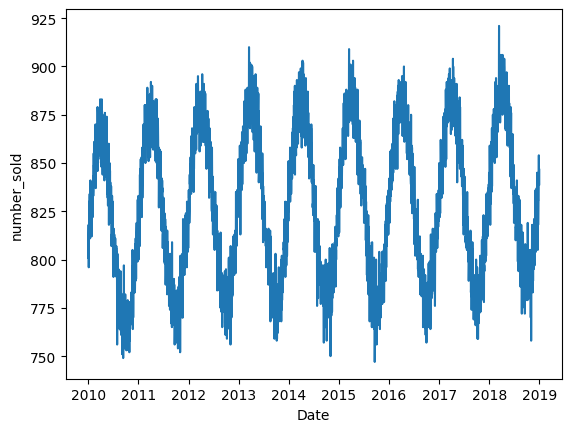

In [11]:
# EDA Plot
sample_data = train_df[(train_df['store'] == 0) & (train_df['product'] == 0)]
sns.lineplot(x='Date', y='number_sold', data=sample_data)
plt.show()

In [12]:
# Add lagged variables
def add_lagged_variables(df, lag_count=1):
    new_df = df.copy()
    for i in range(1, lag_count + 1):
        new_df[f'lag_{i}'] = new_df['number_sold'].shift(i)
    return new_df.dropna()

single_store_product_data = train_df[(train_df['store'] == 0) & (train_df['product'] == 0)]
lagged_data = add_lagged_variables(single_store_product_data, 3)

In [13]:
# Prepare features and target variable
features = [f'lag_{i}' for i in range(1, 4)]
X = lagged_data[features]
y = lagged_data['number_sold']

In [14]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# Split the data
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=False)

# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred_val = rf_model.predict(X_val)
mape_val = mean_absolute_percentage_error(y_val, y_pred_val)
print(f'MAPE on Validation Set: {mape_val}')

MAPE on Validation Set: 0.0119676492485089


In [16]:
# Feature importance
feature_importances = rf_model.feature_importances_
print(f'Feature Importances: {feature_importances}')

# Prepare test data and evaluate
# (Note: For the full pipeline, you would preprocess the test data similarly to the training data)
y_pred_test = rf_model.predict(X_val)  # Using validation set as a stand-in for demonstration
mape_test = mean_absolute_percentage_error(y_val, y_pred_test)
print(f'MAPE on Test Set: {mape_test}')

Feature Importances: [0.49107474 0.29835262 0.21057264]
MAPE on Test Set: 0.0119676492485089


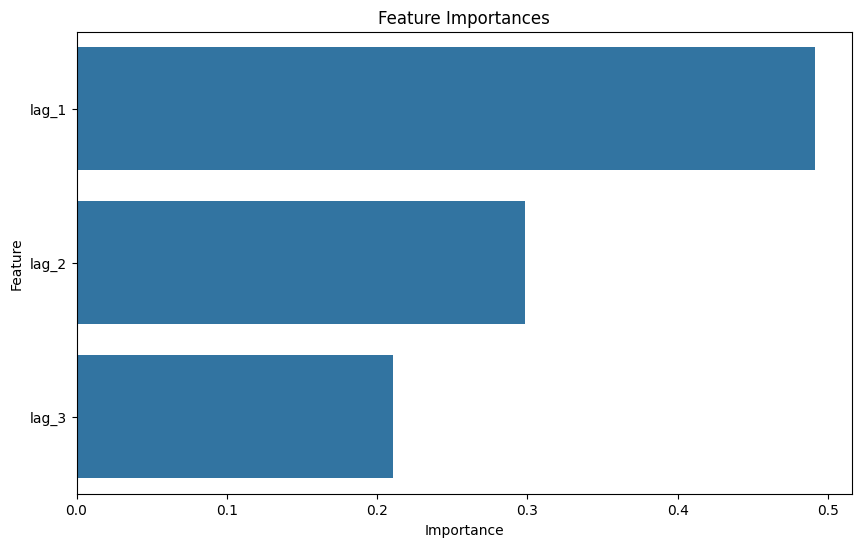

,Feature,Importance
0,lag_1,0.491075
1,lag_2,0.298353
2,lag_3,0.210573


In [17]:
# Extract feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, orient='h')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

feature_importance_df

In [18]:
import pandas as pd

train_df = pd.read_csv("train.csv")

store_sales = (
    train_df.groupby("store")["number_sold"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store
4    32021480
5    29265185
6    28717694
0    27858028
2    26848798
1    23655292
3    11316811
Name: number_sold, dtype: int64

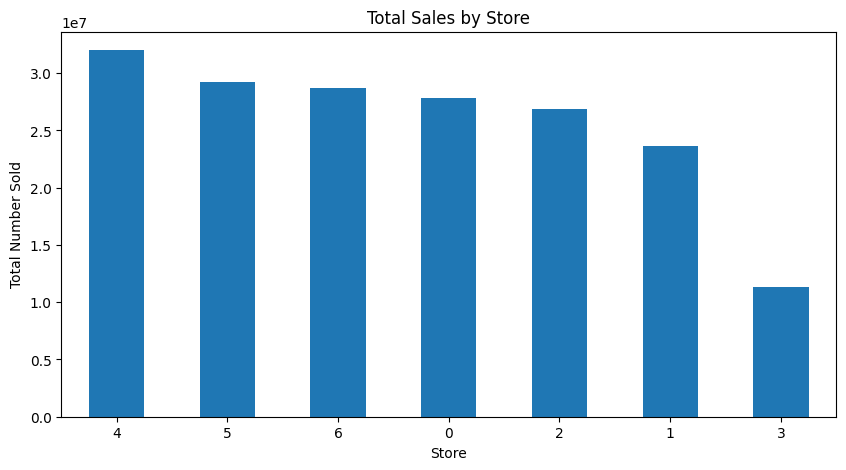

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train.csv")

store_sales = (
    train_df.groupby("store")["number_sold"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Number Sold")
plt.xticks(rotation=0)
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train.csv")

product_sales = (
    train_df.groupby("product")["number_sold"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

product
7    19145173
4    18863984
1    18498184
6    18486872
5    18461564
9    18043066
2    17881926
3    17004993
0    16712918
8    16584608
Name: number_sold, dtype: int64

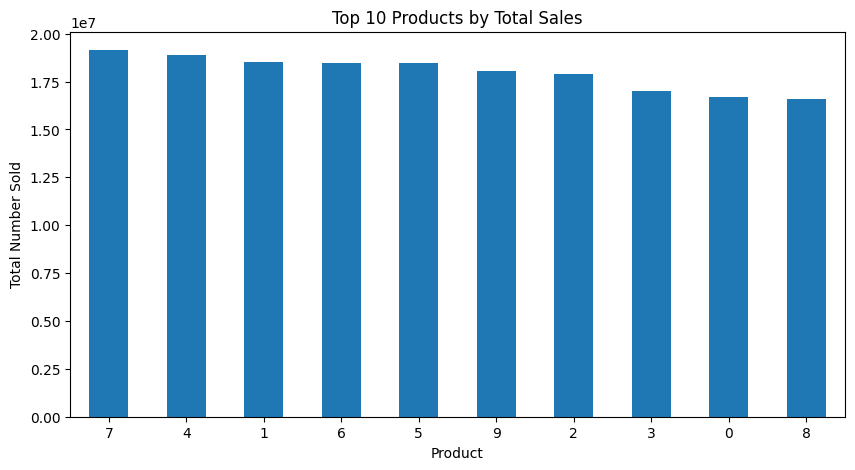

In [21]:
plt.figure(figsize=(10, 5))

product_sales.head(10).plot(kind="bar")

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Number Sold")
plt.xticks(rotation=0)
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train.csv")

train_df["Date"] = pd.to_datetime(train_df["Date"])

monthly_sales = (
    train_df.groupby(train_df["Date"].dt.to_period("M"))["number_sold"]
    .sum()
)

monthly_sales.head()

Date
2010-01    1698403
2010-02    1529750
2010-03    1688388
2010-04    1630998
2010-05    1685240
Freq: M, Name: number_sold, dtype: int64

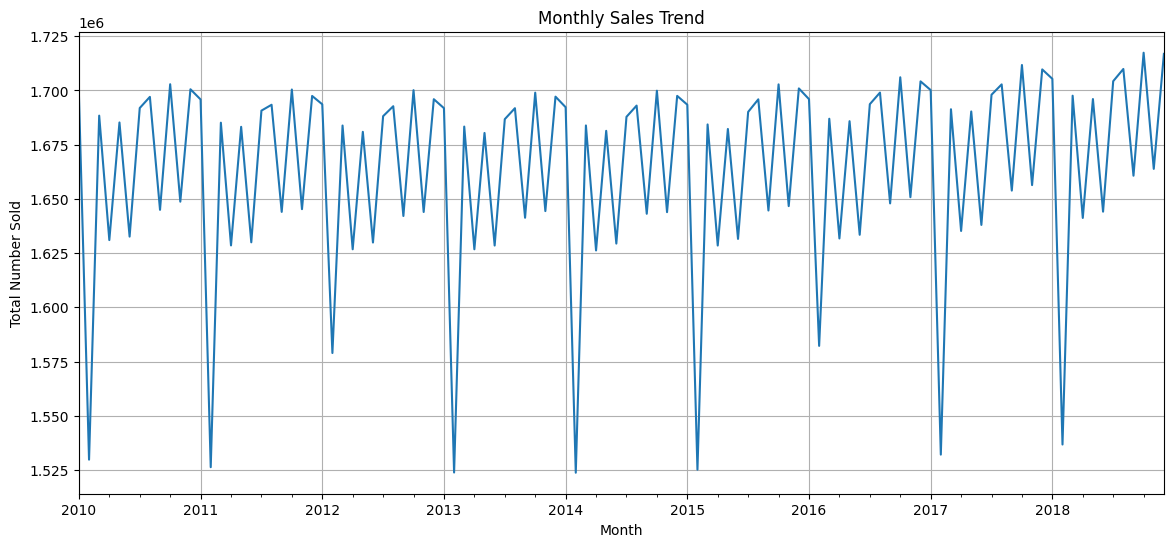

In [23]:
plt.figure(figsize=(14, 6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Number Sold")
plt.grid(True)
plt.show()

In [24]:
yearly_sales = (
    train_df.groupby(train_df["Date"].dt.year)["number_sold"]
    .sum()
)

yearly_sales

Date
2010    19951393
2011    19920275
2012    19956937
2013    19895009
2014    19902095
2015    19926216
2016    20017834
2017    20019537
2018    20093992
Name: number_sold, dtype: int64

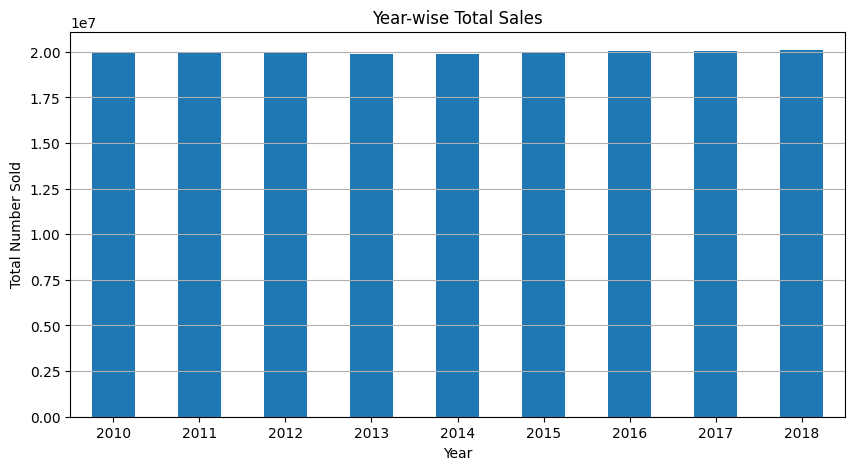

In [25]:
plt.figure(figsize=(10, 5))

yearly_sales.plot(kind="bar")

plt.title("Year-wise Total Sales")
plt.xlabel("Year")
plt.ylabel("Total Number Sold")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [26]:
yoy_growth = yearly_sales.pct_change() * 100

yoy_growth

Date
2010         NaN
2011   -0.155969
2012    0.184044
2013   -0.310308
2014    0.035617
2015    0.121198
2016    0.459786
2017    0.008507
2018    0.371912
Name: number_sold, dtype: float64

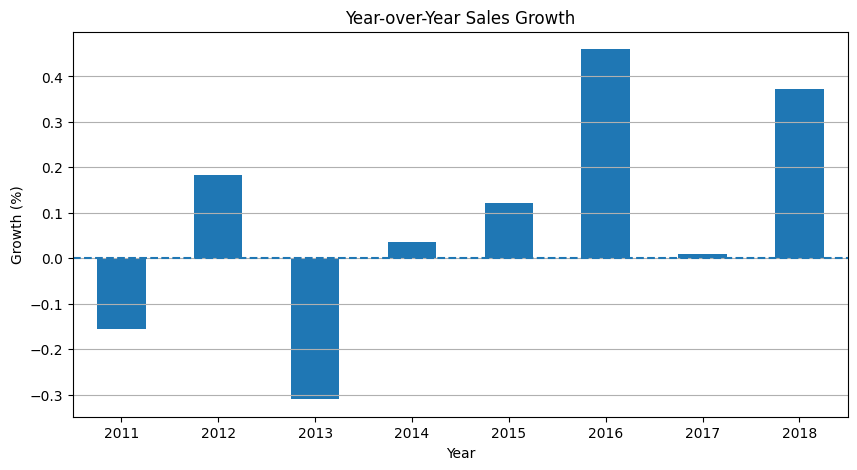

In [27]:
plt.figure(figsize=(10, 5))

yoy_growth.dropna().plot(kind="bar")

plt.title("Year-over-Year Sales Growth")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.xticks(rotation=0)
plt.axhline(y=0, linestyle="--")
plt.grid(axis="y")
plt.show()

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_val = rf_model.predict(X_val)

mape_rf = mean_absolute_percentage_error(
    y_val,
    y_pred_val
)

# Linear Regression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

mape_lr = mean_absolute_percentage_error(
    y_val,
    y_pred_lr
)

# Results
print("Random Forest MAPE:", round(mape_rf, 4))
print("Linear Regression MAPE:", round(mape_lr, 4))

Random Forest MAPE: 0.012
Linear Regression MAPE: 0.0112


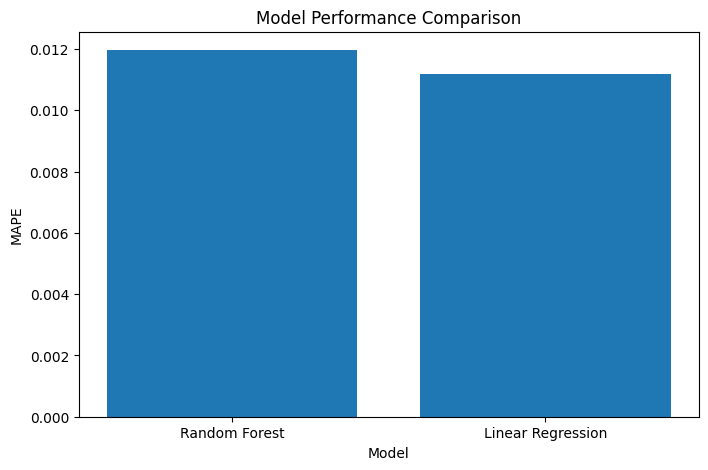

In [29]:
models = ["Random Forest", "Linear Regression"]
mape_scores = [mape_rf, mape_lr]

plt.figure(figsize=(8, 5))
plt.bar(models, mape_scores)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("MAPE")
plt.show()

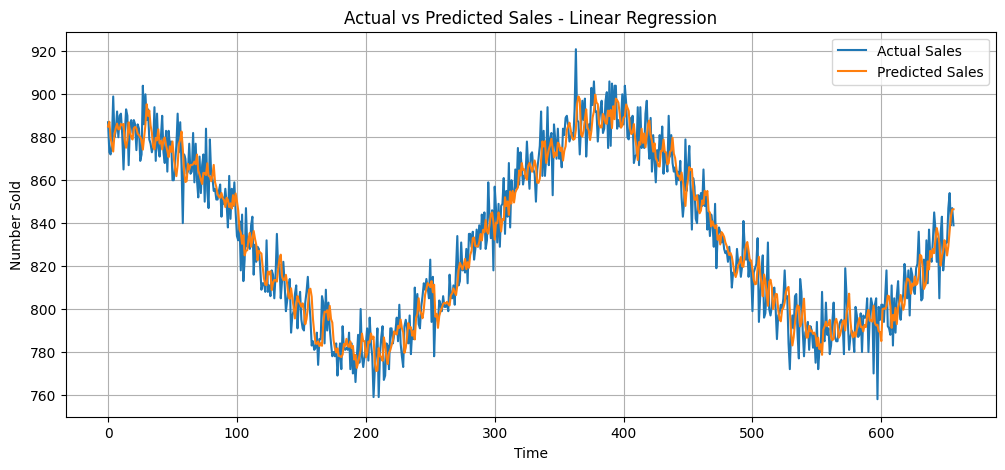

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(y_val.values, label="Actual Sales")
plt.plot(y_pred_lr, label="Predicted Sales")

plt.title("Actual vs Predicted Sales - Linear Regression")
plt.xlabel("Time")
plt.ylabel("Number Sold")
plt.legend()
plt.grid(True)

plt.show()

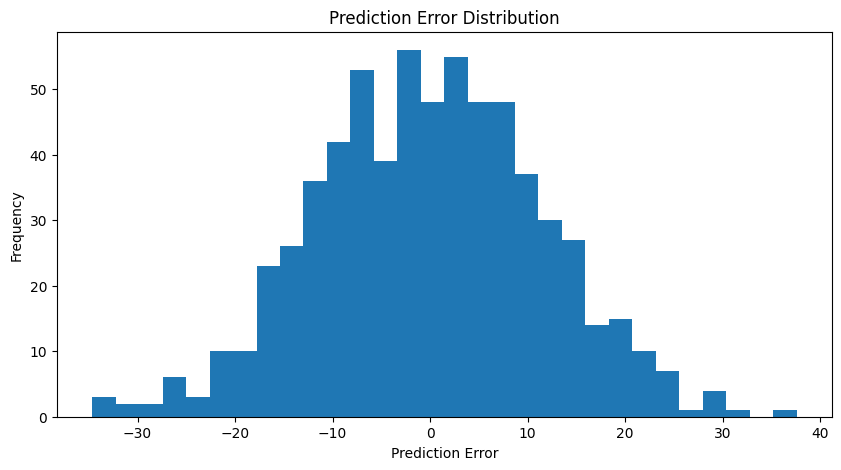

In [31]:
errors = y_val.values - y_pred_lr

plt.figure(figsize=(10, 5))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

## Business Insights

### Key Findings

1. Store 4 generated the highest total sales.
2. Product 7 recorded the highest sales.
3. Monthly sales showed variations across different periods.
4. Yearly sales remained relatively stable.
5. Year-over-year analysis showed small fluctuations in annual sales growth.
6. Linear Regression achieved a slightly lower MAPE than Random Forest.
7. Actual vs Predicted analysis was used to evaluate model performance.
8. Prediction error distribution was analyzed to understand model errors.

### Business Recommendations

- Focus inventory planning on high-performing stores and products.
- Monitor monthly demand fluctuations.
- Use historical sales trends for demand planning.
- Use the forecasting model to support future sales estimation.

In [32]:
# Export cleaned sales data for Power BI

powerbi_data = train_df.copy()

powerbi_data["Date"] = pd.to_datetime(powerbi_data["Date"])

powerbi_data["Year"] = powerbi_data["Date"].dt.year
powerbi_data["Month"] = powerbi_data["Date"].dt.month
powerbi_data["Month_Name"] = powerbi_data["Date"].dt.strftime("%B")

powerbi_data.to_csv("sales_powerbi.csv", index=False)

print("Power BI dataset created successfully!")
print("Rows:", len(powerbi_data))
print("Columns:", len(powerbi_data.columns))

Power BI dataset created successfully!
Rows: 230090
Columns: 7


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

In [34]:
def add_lagged_variables(df, lag_count=1):
    new_df = df.copy()
    for i in range(1, lag_count + 1):
        new_df[f'lag_{i}'] = new_df['number_sold'].shift(i)
    return new_df.dropna()

single_store_product_data = train_df[
    (train_df['store'] == 0) & 
    (train_df['product'] == 0)
]

lagged_data = add_lagged_variables(single_store_product_data, 3)

# Prepare features and target variable
features = [f'lag_{i}' for i in range(1, 4)]

X = lagged_data[features]
y = lagged_data['number_sold']

print("Lagged data:", lagged_data.shape)
print("X:", X.shape)
print("y:", y.shape)

Lagged data: (3284, 7)
X: (3284, 3)
y: (3284,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("X_scaled:", X_scaled.shape)

X_scaled: (3284, 3)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (2627, 3)
X_val: (657, 3)
y_train: (2627,)
y_val: (657,)


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Create and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_val)

# Evaluate model
mape_lr = mean_absolute_percentage_error(y_val, y_pred_lr)

print(f"Linear Regression MAPE: {mape_lr:.4f}")

Linear Regression MAPE: 0.0112


In [38]:
forecast_data = pd.DataFrame({
    "Actual_Sales": y_val.values,
    "Predicted_Sales": y_pred_lr
})

forecast_data.to_csv(
    "sales_forecast_powerbi.csv",
    index=False
)

print("Forecast dataset created successfully!")
print("Rows:", len(forecast_data))
print(forecast_data.head())

Forecast dataset created successfully!
Rows: 657
   Actual_Sales  Predicted_Sales
0           887       885.025700
1           873       887.246584
2           872       879.627700
3           878       876.534502
4           899       873.349391


In [39]:
# Create forecast dataset with dates
forecast_data = pd.DataFrame({
    "Date": lagged_data.loc[y_val.index, "Date"].values,
    "Actual_Sales": y_val.values,
    "Predicted_Sales": y_pred_lr
})

forecast_data.to_csv(
    "sales_forecast_powerbi.csv",
    index=False
)

print(forecast_data.head())
print("Rows:", len(forecast_data))

        Date  Actual_Sales  Predicted_Sales
0 2017-03-15           887       885.025700
1 2017-03-16           873       887.246584
2 2017-03-17           872       879.627700
3 2017-03-18           878       876.534502
4 2017-03-19           899       873.349391
Rows: 657


In [40]:
forecast_data = pd.DataFrame({
    "Date": lagged_data.loc[y_val.index, "Date"].values,
    "Actual_Sales": y_val.values,
    "Predicted_Sales": y_pred_lr
})

print(forecast_data.columns.tolist())
print(forecast_data.head())

forecast_data.to_csv(
    "sales_forecast_powerbi.csv",
    index=False
)

['Date', 'Actual_Sales', 'Predicted_Sales']
        Date  Actual_Sales  Predicted_Sales
0 2017-03-15           887       885.025700
1 2017-03-16           873       887.246584
2 2017-03-17           872       879.627700
3 2017-03-18           878       876.534502
4 2017-03-19           899       873.349391


In [43]:
# Create prediction DataFrame using y_val index
prediction_df = pd.DataFrame({
    'Date': lagged_data.loc[y_val.index, 'Date'].values,
    'Actual_Sales': y_val.values,
    'Predicted_Sales': y_pred_val
})

# Check output
print(prediction_df.head())
print("\nColumns:")
print(prediction_df.columns.tolist())

        Date  Actual_Sales  Predicted_Sales
0 2017-03-15           887           881.73
1 2017-03-16           873           878.27
2 2017-03-17           872           874.92
3 2017-03-18           878           875.61
4 2017-03-19           899           869.89

Columns:
['Date', 'Actual_Sales', 'Predicted_Sales']


In [44]:
prediction_df.to_csv('sales_predictions.csv', index=False)

print("sales_predictions.csv created successfully!")

sales_predictions.csv created successfully!


In [3]:
import pandas as pd

# Load train data
train_df = pd.read_csv("train.csv")

# Convert Date
train_df["Date"] = pd.to_datetime(train_df["Date"])

# Function for lag variables
def add_lagged_variables(df, lag_count=3):
    new_df = df.copy()

    for i in range(1, lag_count + 1):
        new_df[f"lag_{i}"] = new_df["number_sold"].shift(i)

    return new_df.dropna()

# Store 0 + Product 0
single_store_product_data = train_df[
    (train_df["store"] == 0) &
    (train_df["product"] == 0)
]

# Create lag data
lagged_data = add_lagged_variables(
    single_store_product_data,
    3
)

# Features and target
features = ["lag_1", "lag_2", "lag_3"]

X = lagged_data[features]
y = lagged_data["number_sold"]

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

# Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_val)

# Create forecast dataset
forecast_data = pd.DataFrame({
    "Date": lagged_data.loc[y_val.index, "Date"].values,
    "Actual_Sales": y_val.values,
    "Predicted_Sales": y_pred_lr
})

# Check
print(forecast_data.head(10))

print("\nColumns:")
print(forecast_data.columns.tolist())

print("\nAre Actual and Predicted same?")
print(
    forecast_data["Actual_Sales"].equals(
        forecast_data["Predicted_Sales"]
    )
)

# Save CSV
forecast_data.to_csv(
    "sales_forecast_powerbi.csv",
    index=False
)

print("\n✅ sales_forecast_powerbi.csv created successfully!")

        Date  Actual_Sales  Predicted_Sales
0 2017-03-15           887       885.025700
1 2017-03-16           873       887.246584
2 2017-03-17           872       879.627700
3 2017-03-18           878       876.534502
4 2017-03-19           899       873.349391
5 2017-03-20           880       881.599635
6 2017-03-21           883       884.327838
7 2017-03-22           892       886.358341
8 2017-03-23           880       883.702125
9 2017-03-24           890       883.792081

Columns:
['Date', 'Actual_Sales', 'Predicted_Sales']

Are Actual and Predicted same?
False

✅ sales_forecast_powerbi.csv created successfully!
